In [1]:

import cProfile
import time

import numpy as np
import matplotlib.pyplot as plt
from mandelbrot import (
    bench,
    compute_mandelbrot_numpy,
    compute_sums_columns,
    compute_sums_row,
    mandelbrot_naive,
    compute_mandelbrot_naive_numba,
    compute_mandelbrot_hybrid,
    compute_mandelbrot_numba_float64,
    compute_mandelbrot_numba_float32,
    compute_mandelbrot_numba_float16
)
import cProfile
import pstats



Compare naive vs numpy

In [2]:
start = time.time()
# Compute 1024x1024 grid with 100 max iterations
arr = mandelbrot_naive(-2, 1, -1.5, 1.5, 1024, 1024, 100)
elapsed = time.time() - start
print(f"computation took {elapsed:.3f} seconds for naive")

start = time.time()
# Compute 1024x1024 grid with 100 max iterations
arr = compute_mandelbrot_numpy(-2, 1, -1.5, 1.5, 1024, 1024, 100)
elapsed = time.time() - start
print(f"computation took {elapsed:.3f} seconds for numpy")



computation took 1.866 seconds for naive
computation took 0.885 seconds for numpy


Compare differen size for naive, with warmup

In [5]:
sizes = [256, 512, 1024, 2048, 4096]

for n in sizes:
    t_med, t_min, t_max = bench(
        compute_mandelbrot_numpy, -2, 1, -1.5, 1.5, n, n, 100, False
    )
    print(f"{n}x{n}: median={t_med:.4f}s (min={t_min:.4f}, max={t_max:.4f})")


256x256: median=0.0189s (min=0.0183, max=0.0245)
512x512: median=0.1786s (min=0.1728, max=0.1817)
1024x1024: median=0.9064s (min=0.8931, max=0.9158)
2048x2048: median=3.7025s (min=3.6268, max=3.7322)
4096x4096: median=15.1421s (min=14.8928, max=16.4106)


Comparing col sum vs row sum
and comparing using numpy asfor trannary

In [6]:
N = 5000
A = np.random.rand(N, N)
AF = np.asfortranarray(A)

tests = [
    ("Normal row sum", compute_sums_row, A, N),
    ("Normal column sum", compute_sums_columns, A, N),
    ("row_sum asfortranarray", compute_sums_row, AF, N),
    ("col_sum asfortranarray", compute_sums_columns, AF, N),
]

for name, fn, arr, n in tests:
    t_med, t_min, t_max = bench(fn, arr, n, warmup=False)
    print(f"{name}: median={t_med:.4f}s (min={t_min:.4f}, max={t_max:.4f})")
    time.sleep(2)

Normal row sum: median=0.0300s (min=0.0274, max=0.0322)
Normal column sum: median=0.1686s (min=0.1629, max=0.1844)
row_sum asfortranarray: median=0.1752s (min=0.1734, max=0.1798)
col_sum asfortranarray: median=0.0301s (min=0.0292, max=0.0306)


**Lecture 3**

In [11]:
cProfile.run('mandelbrot_naive(-2, 1, -1.5, 1.5, 1024, 1024, 100, show=False)', 'naive_profile.prof')
cProfile.run('compute_mandelbrot_numpy(-2, 1, -1.5, 1.5, 1024, 1024, 100, show=False)', 'numpy_profile.prof')

for name in ('naive_profile.prof', 'numpy_profile.prof'):
   stats = pstats.Stats(name)
   stats.sort_stats('cumulative')
   stats.print_stats(10)


Tue Mar  3 17:09:30 2026    naive_profile.prof

         21959910 function calls (21959907 primitive calls) in 2.409 seconds

   Ordered by: cumulative time
   List reduced from 90 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
 21959734    1.659    0.000    1.659    0.000 {built-in method builtins.abs}
        2    0.000    0.000    1.128    0.564 C:\Users\morte\AppData\Local\Programs\Python\Python312\Lib\asyncio\base_events.py:1922(_run_once)
        1    0.000    0.000    1.112    1.112 {built-in method builtins.exec}
        1    0.000    0.000    1.112    1.112 <string>:1(<module>)
        1    0.726    0.726    1.112    1.112 c:\Users\morte\OneDrive\Desktop\numerical_scientific_computing\mandelbrot.py:19(mandelbrot_naive)
        1    0.000    0.000    0.016    0.016 C:\Users\morte\AppData\Local\Programs\Python\Python312\Lib\selectors.py:319(select)
        1    0.000    0.000    0.016    0.016 C:\Users\morte\AppData\Local\P


Q1: Which function takes most total time?

A: The naive method takes longer. Naive takkes 0.963 s. , compared too 0.401 s.

Q2: Are there functions called surprisingly many times?

A: The escape call inside the naive method, it is being called 5.481.530.

Q3: How does NumPy profile compare to naive?

A: It is faster not spending much time with pythohn calls. The naive spend a lot of time doing python level calls such as abs

Q4: Where does NumPy spend its time?

A: It spends it´s time in c.
Almost all runtime is in compute_mandelbrot_numpy cumtime: 0.190 s, which delegates work to Numpys compiled array operations.
The only visible Python-level costs are small one-off array constructions like meshgrid 0.001 s and zeros_like 0.001 .


**Milestone 2**


Q1: cProfile on naive vs NumPy: How many functions appear in each profile? What does this difference tell you about where the work actually happens?
A: Naive: ~5.5 million inner-loop executions, NumPy: ~100 vectorized operations

Q2: line profiler on naive: Which lines dominate runtime? What fraction of total time is spent in the inner loop?
A: the lines in the inner loop is where the is used most time.

Q3: Based on your profiling results: why is NumPy faster than naive Python?
A: numpy does not have multiple nested loops, which it has to call many millions times.

Q4: What would you need to change to make the naive version faster? (hint: what does line profiler tell you about the inner loop?)
A: Not use abs(), pre-allocate the list, thus not using append. because it removes the possibility of re allocating memory for the list


**Milestone 3**

In [17]:
compute_mandelbrot_naive_numba(-2, 1, -1.5, 1.5, 1024, 1024, 100)
compute_mandelbrot_hybrid(-2, 1, -1.5, 1.5, 1024, 1024, 100)
tf_median, tf_min, tf_max = bench(compute_mandelbrot_naive_numba, -2, 1, -1.5, 1.5, 1024, 1024, 100, runs=1)
th_median, th_min, th_max = bench(compute_mandelbrot_hybrid, -2, 1, -1.5, 1.5, 1024, 1024, 100, runs=1)

print(f"Hybrid: {th_median:.3f}s")
print(f"Fully compiled: {tf_median:.3f}s")
print(f"Ratio: {th_median/tf_median:.1f}x")


Hybrid: 1.587s
Fully compiled: 0.043s
Ratio: 37.0x


**Milestone 4**

Max diff float32 vs float64: 33


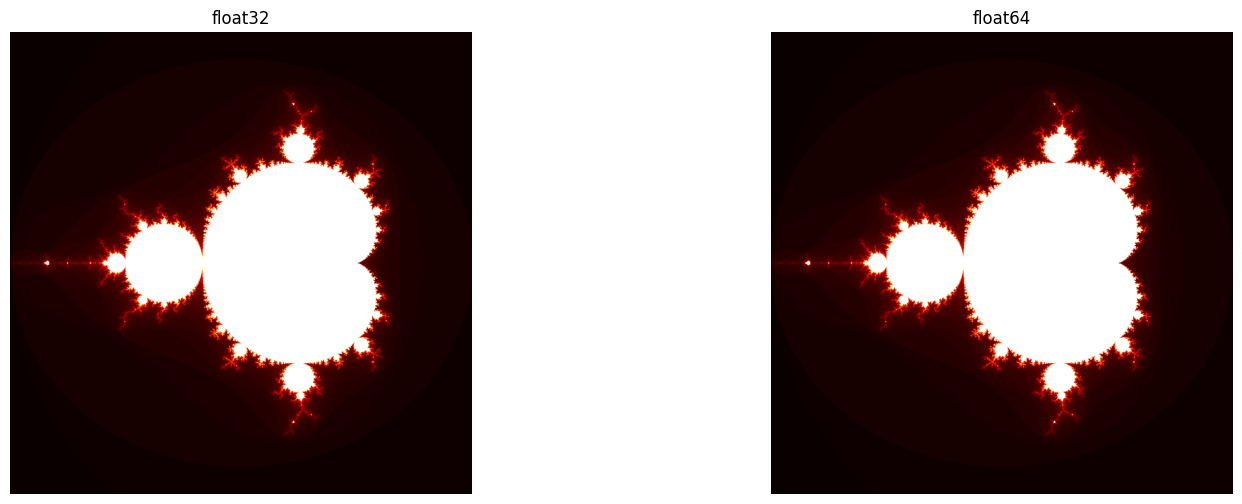

In [4]:


r32 = compute_mandelbrot_numba_float32(-2, 1, -1.5, 1.5, 1024, 1024, 100)
r64 = compute_mandelbrot_numba_float64(-2, 1, -1.5, 1.5, 1024, 1024, 100)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, result, title in zip(axes, [r32, r64], ['float32', 'float64']):
    ax.imshow(result, cmap='hot')
    ax.set_title(title); ax.axis('off')
plt.savefig('precision_comparison.png', dpi=150)
print(f"Max diff float32 vs float64: {np.abs(r32 - r64).max()}")


Q1: Speed: Does float32 actually run faster than float64 on your hardware?
A: Sometimes it is sligthly faster but nothing noticable around 0.002

Q2: By how much?
A: 0.002

Q3: float16: Try it with NumPy — is it faster than float32?
A: i would not run on my pc, it just gave error saying float16. I would assume it is slightly faster again

Q4: Visual quality: Zoom in on a detailed region of the Mandelbrot set. Can you see artefacts with float16?
A: Yes. I can see artifacts
Q5: What about float32?
A: Yes. I can still see artifacts

Q6: Recommendation: Based on what you observe, which precision would you choose for production use, and why?
A: i would use float 32 because it is slightly faster than 64, thus giving evidence for it being faster. and i can still see aritfacts. float 32 has a lower precision but the tradeoff in performance is not visually.